# Notebook 1: Data preparation

This is the original project analysis. The 2026 revisit only adds repository-relative paths and publication context; the scientific workflow and saved outputs are intentionally preserved.

Importerer nødvendige pakker:

In [1503]:
import numpy as np
from numpy import sort
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DATA_DIR = PROJECT_ROOT / 'data' / 'course' / 'raw'
SAMPLE_DATA_DIR = PROJECT_ROOT / 'data' / 'course' / 'sample'
PROCESSED_DATA_DIR = PROJECT_ROOT / 'data' / 'processed'

# DATAFORBEREDELSE

Laster inn raw data fra de fire filene:

In [1504]:
demographic_raw_df = pd.read_csv(RAW_DATA_DIR / 'demographic.csv')
hospital_raw_df = pd.read_csv(RAW_DATA_DIR / 'hospital.csv')
physiological_raw_df = pd.read_csv(RAW_DATA_DIR / 'physiological.txt', delimiter='\t')
severity_raw_df = pd.read_json(RAW_DATA_DIR / 'severity.json')

Laster også inn SAMPLE DATA, dette er data som ikke trenger å renses på noen som helst måte, men som skal brukes til predikering når modellen er ferdig. For å kunne predikere oppholdslenge på sample data må dataen inneholde akkurat de samme variablene og datatypene som modellen ble trent med i utgangspunktet. Derfor må sample data også behandles i enkelte tilfeller for å sikre dette.

In [1505]:
demographic_sample_df = pd.read_csv(SAMPLE_DATA_DIR / 'demographic.csv')
hospital_sample_df = pd.read_csv(SAMPLE_DATA_DIR / 'hospital.csv')
physiological_sample_df = pd.read_csv(SAMPLE_DATA_DIR / 'physiological.txt', delimiter='\t')
severity_sample_df = pd.read_json(SAMPLE_DATA_DIR / 'severity.json')

Begynner med å se litt på de fire ulike filene med rådata og hvilke typer data de inneholder. Det er viktig å studere datasettene for å vite hvordan man skal rense og bearbeide dataen.

In [1506]:
physiological_sample_df.min()

pasient_id                1.000000
blodtrykk                 0.000000
hvite_blodlegemer         0.069992
hjertefrekvens            0.000000
respirasjonsfrekvens      0.000000
kroppstemperatur         32.000000
lungefunksjon            33.000000
serumalbumin              0.899902
bilirubin                 0.099991
kreatinin                 0.199982
natrium                 112.000000
blod_ph                   7.059570
glukose                  36.000000
blodurea_nitrogen         1.899902
urinmengde                0.000000
dtype: float64

##### Demografisk data
Begynner å se på demograpic raw data som er forventet å inneholde en del kategorisk data:

In [1507]:
demographic_raw_df.columns

Index(['pasient_id', 'alder', 'kjønn', 'utdanning', 'inntekt', 'etnisitet'], dtype='object')

In [1508]:
demographic_raw_df.head()


,pasient_id,alder,kjønn,utdanning,inntekt,etnisitet
0,2,60.33899,female,12.0,$11-$25k,white
1,3,52.74698,female,12.0,under $11k,white
2,4,42.38498,female,11.0,under $11k,white
3,5,79.88495,female,NaN,NaN,white
4,6,93.01599,male,14.0,NaN,white


In [1509]:
demographic_raw_df.describe()

,pasient_id,alder,utdanning
count,7742.000000,7742.000000,6360.000000
mean,4539.500517,62.710904,11.752987
std,2637.118792,15.688113,3.458671
min,2.000000,-1.000000,0.000000
25%,2243.250000,52.915240,10.000000
50%,4538.500000,65.008000,12.000000
75%,6815.750000,74.131487,14.000000
max,9105.000000,101.847960,31.000000


Kun pasient_id, alder og utdanning er numeriske. Ser at alder sin minimumsverdi er negativ, noe som åpenbart ikke er en gyldig verdi, velger å erstatt negative verdier i kolonnen 'alder' med NaN:

In [1510]:
demographic_raw_df.loc[demographic_raw_df['alder'] < 0, 'alder'] = np.nan

Sjekker deretter for rader med identisk pasient_id, duplikate rader fjernes:

In [1511]:
demographic_raw_df = demographic_raw_df.drop_duplicates(subset='pasient_id', keep='first')

Katagoriske variabler som kjønn, inntekt og etnisitet må gjøres numerisk. Sjekker først de unike verdiene i inntektskolonner slik at jeg kan mappe inntekt om til numersike verdier:

In [1512]:
print(f"Unike verdier i inntektskolonnen: {demographic_raw_df["inntekt"].unique()}")

Unike verdier i inntektskolonnen: ['$11-$25k' 'under $11k' nan '$25-$50k' '>$50k']


Inntektskolonnen inneholder data som er vanskelig å arbeide med. Det er fire lønnsklasser, inkludert NaN verdier. Disse må håndteres. Jeg velger å gjøre lønnsdata numerisk på følgende måte:

0: under $11k,
1: $11-$25k,
2: $25-$50k,
3: >$50k

In [1513]:
def map_income_to_code(df):
    # Definerer mappingen for inntektsnivåer
    income_mapping = {
        'under $11k': 0,
        '$11-$25k': 1,
        '$25-$50k': 2,
        '>$50k': 3
    }

    # Definerer en ny kolonne som bruker mappingen til inntekt
    df['inntekt_kode'] = df['inntekt'].map(income_mapping)

    # Fjerner inntektskolonnen
    df = df.drop(columns=['inntekt'])

    return df

demographic_raw_df = map_income_to_code(demographic_raw_df)
demographic_sample_df = map_income_to_code(demographic_sample_df)


Studerer etnisitetsvariabelen litt nærmere ...

In [1514]:
etnisitet_counts = demographic_raw_df['etnisitet'].value_counts()
print(etnisitet_counts)

etnisitet
white       6118
black       1174
hispanic     254
other         91
asian         66
Name: count, dtype: int64


Gjør nå kolonnene "etnisitet" og "kjønn" numerisk":

In [1515]:
demographic_raw_df = pd.get_dummies(demographic_raw_df, columns=['etnisitet', 'kjønn'])
demographic_raw_df.columns

#Gjør tilsvarende for sample data
demographic_sample_df = pd.get_dummies(demographic_sample_df, columns=['etnisitet', 'kjønn'])


Kolonnene "kjønn_female" og "kjønn_male" er  "mutually exclusive" (gjensidig utelukkende). Kan derfor fjerne én av dem uten å miste informasjon. Feks når "kjønn_male" er 0, vil "kjønn_female" alltid være 1:

In [1516]:
demographic_raw_df = demographic_raw_df.drop(columns=['kjønn_female'])

#Gjør tilsvarende for sample data
demographic_sample_df = demographic_sample_df.drop(columns=['kjønn_female'])

I denne analysen, hvor målet er å forutsi oppholdslengde, ser jeg på det som unødvendig å ha fem kolonner for etnisitet. Jeg velger derfor å lage én kolonne der `1` representerer hvit og `0` representerer minoriteter. For nærmere begrunnelse se rapport (DEMOGRAPHIC DATA).

In [1517]:
def process_ethnicity_column(df):
    # Oppretter en ny kolonne 'etnisitet_w' der 1 er hvit, 0 er minoritet
    df['etnisitet_w'] = 0  
    df.loc[df['etnisitet_white'] == 1, 'etnisitet_w'] = 1 

    # Fjerner de gamle dummykolonnene
    df = df.drop(columns=['etnisitet_asian', 'etnisitet_black',
                          'etnisitet_hispanic', 'etnisitet_other', 'etnisitet_white'])

    return df

demographic_raw_df = process_ethnicity_column(demographic_raw_df)
demographic_sample_df = process_ethnicity_column(demographic_sample_df)

In [1518]:
demographic_raw_df.columns

Index(['pasient_id', 'alder', 'utdanning', 'inntekt_kode', 'kjønn_male',
       'etnisitet_w'],
      dtype='object')

##### Hospital data

In [1519]:
hospital_raw_df.columns

Index(['pasient_id', 'sykehusdød', 'oppholdslengde'], dtype='object')

In [1520]:
hospital_raw_df.head()

,pasient_id,sykehusdød,oppholdslengde
0,2,1,4
1,3,0,17
2,4,0,3
3,5,0,-99
4,6,1,4


In [1521]:
hospital_raw_df.describe()

,pasient_id,sykehusdød,oppholdslengde
count,7740.000000,7740.000000,7740.000000
mean,4540.665375,0.263178,17.728682
std,2636.463416,0.440387,21.995401
min,2.000000,0.000000,-99.000000
25%,2244.750000,0.000000,6.000000
50%,4539.500000,0.000000,11.000000
75%,6816.250000,1.000000,20.000000
max,9105.000000,1.000000,343.000000


Minimumsverdien for oppholdslengde er -99, som er en ugyldig verdi. Ettersom oppholdslengde er vår målvariabel, det vil si det vi skal predikere på usett data, har jeg besluttet å fjerne rader med ugyldige oppholdslengdeverdier. Det er viktig å merke seg at det generelt er dårlig praksis å imputere (fylle inn) manglende verdier for målvariabelen.

I tillegg vil jeg også fjerne eventuelle duplikater av `pasient_id` for å sikre datakvaliteten.


In [1522]:
hospital_raw_df = hospital_raw_df[hospital_raw_df['oppholdslengde'] >= 0]

hospital_raw_df = hospital_raw_df.drop_duplicates(subset='pasient_id', keep='first')

##### Physiological Data

In [1523]:
physiological_raw_df.columns

Index(['pasient_id', 'blodtrykk', 'hvite_blodlegemer', 'hjertefrekvens',
       'respirasjonsfrekvens', 'kroppstemperatur', 'lungefunksjon',
       'serumalbumin', 'bilirubin', 'kreatinin', 'natrium', 'blod_ph',
       'glukose', 'blodurea_nitrogen', 'urinmengde'],
      dtype='object')

In [1524]:
physiological_raw_df.head()

,pasient_id,blodtrykk,hvite_blodlegemer,hjertefrekvens,respirasjonsfrekvens,kroppstemperatur,lungefunksjon,serumalbumin,bilirubin,kreatinin,natrium,blod_ph,glukose,blodurea_nitrogen,urinmengde
0,2,43.0,17.097656,112.0,34.0,34.59375,98.00000,NaN,NaN,5.500000,132.0,7.250000,NaN,NaN,NaN
1,3,70.0,8.500000,88.0,28.0,37.39844,231.65625,NaN,2.199707,2.000000,134.0,7.459961,NaN,NaN,NaN
2,4,75.0,9.099609,88.0,32.0,35.00000,NaN,NaN,NaN,0.799927,139.0,NaN,NaN,NaN,NaN
3,5,59.0,13.500000,112.0,20.0,37.89844,173.31250,NaN,NaN,0.799927,143.0,7.509766,NaN,NaN,NaN
4,6,110.0,10.398438,101.0,44.0,38.39844,266.62500,NaN,NaN,0.699951,140.0,7.659180,NaN,NaN,NaN


In [1525]:
physiological_raw_df.describe()

,pasient_id,blodtrykk,hvite_blodlegemer,hjertefrekvens,respirasjonsfrekvens,kroppstemperatur,lungefunksjon,serumalbumin,bilirubin,kreatinin,natrium,blod_ph,glukose,blodurea_nitrogen,urinmengde
count,7740.000000,7740.000000,7565.000000,7740.000000,7740.000000,7740.000000,5796.000000,4891.000000,5544.000000,7683.000000,7740.000000,5828.000000,3917.000000,4048.000000,3627.000000
mean,4540.665375,84.412468,12.302026,97.283940,23.348450,37.116579,239.608379,2.952622,2.565599,1.790278,137.574160,7.415439,160.031146,32.582040,2185.398372
std,2636.463416,27.713746,9.108076,31.499505,9.549561,1.257278,109.942808,0.889463,5.318276,1.711926,6.029887,0.080844,87.828819,26.826593,1458.900940
min,2.000000,0.000000,0.000000,0.000000,0.000000,31.699220,12.000000,0.399963,0.099991,0.099991,110.000000,6.829102,0.000000,1.000000,0.000000
25%,2244.750000,63.000000,6.899414,72.000000,18.000000,36.195310,155.093750,2.399902,0.500000,0.899902,134.000000,7.379883,103.000000,14.000000,1175.000000
50%,4539.500000,77.000000,10.599609,100.000000,24.000000,36.695310,223.984375,2.899902,0.899902,1.199951,137.000000,7.419922,135.000000,23.000000,1963.000000
75%,6816.250000,107.000000,15.298828,120.000000,28.000000,38.195310,304.750000,3.599609,1.899902,1.899902,141.000000,7.469727,190.000000,43.000000,2980.000000
max,9105.000000,195.000000,128.781250,232.000000,90.000000,41.695310,869.375000,29.000000,63.000000,21.500000,181.000000,7.769531,1092.000000,192.000000,9000.000000


Begynner med å fjerne duplikater:

In [1526]:
physiological_raw_df = physiological_raw_df.drop_duplicates(subset='pasient_id', keep='first')

Alle kolonnene i **physiological data** inneholder numeriske verdier. Basert på minimumsverdiene ser jeg at flere av disse kolonnene har verdier satt til 0. Jeg anser disse verdiene som ugyldige, ettersom det ikke er meningsfylt å referere til 0 i sammenheng med blodtrykk eller hjertefrekvens, hvis en pasient hadde disse verdiene, ville det tilsi at vedkommende allerede er død.

Derfor vil jeg konvertere alle disse 0-verdiene til NaN for å sikre at dataene er mer representative og meningsfulle. Disse NaN-verdiene kan heller imputeres på et senere tidspunkt.

In [1527]:
physiological_raw_df.replace(0, np.nan, inplace=True)

#Gjør tilsvarene som sample data:
physiological_sample_df.replace(0, np.nan, inplace=True)

Neste steg innebærer en håndtering av kolonnen for lungefunksjon. Verdiene deles inn i intervaller basert på informasjon om PaO2/FiO2 Ratio (kilde: [LITFL](https://litfl.com/pao2-fio2-ratio/)). Disse intervallene representerer ulike grader av alvorlighet. Deretter konverteres intervallene til numeriske verdier ved hjelp av en mapping-prosess.


In [1528]:
def code_lung_function(df):
    # Definerer intervallene og etikettene
    lung_function_intervals = [-float('inf'), 100, 200, 300, float('inf')]
    labels = ['Kritisk', 'Svært dårlig', 'Moderat', 'God']

    # Deler kolonnen i intervaller
    df['lungefunksjon_kategori'] = pd.cut(
        df['lungefunksjon'], 
        bins=lung_function_intervals, 
        labels=labels, 
        include_lowest=True
    )

    # Definerer en ny kolonne som bruker mappingen til lungefunksjon
    lungefunksjon_mapping = {
        'Kritisk': -2,
        'Svært dårlig': -1,
        'Moderat': 0,
        'God': 1
    }

    # Bruker mapping for å tilordne numeriske koder
    df['lungefunksjon_kode'] = df['lungefunksjon_kategori'].map(lungefunksjon_mapping)

    # Konverterer 'lungefunksjon_kode' til numerisk type
    df['lungefunksjon_kode'] = pd.to_numeric(df['lungefunksjon_kode'], errors='coerce')

    # Fjerner de kategoriske kolonnene
    df = df.drop(columns=['lungefunksjon', 'lungefunksjon_kategori'])

    return df

physiological_raw_df = code_lung_function(physiological_raw_df)
physiological_sample_df = code_lung_function(physiological_sample_df)

physiological_raw_df.columns

Index(['pasient_id', 'blodtrykk', 'hvite_blodlegemer', 'hjertefrekvens',
       'respirasjonsfrekvens', 'kroppstemperatur', 'serumalbumin', 'bilirubin',
       'kreatinin', 'natrium', 'blod_ph', 'glukose', 'blodurea_nitrogen',
       'urinmengde', 'lungefunksjon_kode'],
      dtype='object')

##### Severity Data

Ser til slutt på severity data, dette er en json fil som har blitt konvertert til en dataframe og den krever derfor ekstra behandlig for at vi skal få en dataframe som er lett å jobbe med. Begynner først med å se på stukturen til nåværende dataframe:

In [1529]:
severity_raw_df.columns

Index(['sykdomskategori_id', 'sykdomskategori', 'pasient_id', 'dødsfall',
       'sykdom_underkategori', 'antall_komorbiditeter', 'koma_score',
       'adl_pasient', 'adl_stedfortreder', 'fysiologisk_score',
       'apache_fysiologisk_score', 'overlevelsesestimat_2mnd',
       'overlevelsesestimat_6mnd', 'diabetes', 'demens', 'kreft',
       'lege_overlevelsesestimat_2mnd', 'lege_overlevelsesestimat_6mnd',
       'dnr_status', 'dnr_dag'],
      dtype='object')

In [1530]:
severity_raw_df.head()

,sykdomskategori_id,sykdomskategori,pasient_id,dødsfall,sykdom_underkategori,antall_komorbiditeter,koma_score,adl_pasient,adl_stedfortreder,fysiologisk_score,apache_fysiologisk_score,overlevelsesestimat_2mnd,overlevelsesestimat_6mnd,diabetes,demens,kreft,lege_overlevelsesestimat_2mnd,lege_overlevelsesestimat_6mnd,dnr_status,dnr_dag
0,A1s,ARF/MOSF,"[5, 15, 18, 23, 28, 34, 39, 43, 46, 47, 48, 58...","[0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, ...","[ARF/MOSF w/Sepsis, ARF/MOSF w/Sepsis, ARF/MOS...","[1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 2, 0, 3, 1, 3, ...","[26.0, 26.0, 26.0, 0.0, 26.0, 37.0, 0.0, 0.0, ...","[None, None, None, None, None, None, None, Non...","[2.0, None, 0.0, 5.0, 2.0, None, 0.0, None, No...","[23.5, 30.5, 40.296875, 31.6992188, 46.796875,...","[30.0, 39.0, 58.0, 42.0, 85.0, 49.0, 5.0, 76.0...","[0.6348876950000001, 0.590942383, 0.2129821780...","[0.5329589840000001, 0.481994629, 0.1169891360...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[no, no, no, no, yes, no, no, no, no, no, yes,...","[0.899999619, 0.899999619, 0.09999996400000001...","[0.9, 0.9, 0.001, 0.5, 0.000125, 0.60000000000...","[None, None, None, None, None, None, None, Non...","[None, None, None, None, None, None, None, Non..."
1,BrY,COPD/CHF/Cirrhosis,"[2, 3, 7, 8, 11, 13, 14, 19, 20, 30, 31, 32, 3...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, ...","[Cirrhosis, Cirrhosis, CHF, CHF, CHF, Cirrhosi...","[2, 2, 1, 3, 1, 1, 0, 2, 1, 2, 2, 2, 2, 1, 1, ...","[44.0, 0.0, 0.0, 26.0, 0.0, 0.0, 0.0, 0.0, 0.0...","[None, 1.0, 0.0, None, 2.0, 0.0, 0.0, 7.0, 3.0...","[1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 7.0, None,...","[52.6953125, 20.5, 17.296875, 21.5976562, 14.5...","[74.0, 45.0, 46.0, 53.0, 14.0, 30.0, 34.0, 42....","[0.000999928, 0.790893555, 0.892944336, 0.6708...","[0.0, 0.6649169920000001, 0.820922852, 0.49896...","[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[no, no, no, no, no, no, no, no, no, no, no, n...","[0.0, 0.75, None, 0.799999714, 0.699999809, No...","[0.0, 0.5, 0.7000000000000001, 0.4, 0.5, None,...","[None, None, None, None, None, None, None, Non...","[None, None, None, None, None, None, None, Non..."
2,ChE,Cancer,"[4, 9, 10, 12, 16, 17, 21, 24, 27, 41, 42, 54,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, ...","[Lung Cancer, Lung Cancer, Colon Cancer, Lung ...","[2, 2, 0, 0, 1, 2, 0, 0, 0, 1, 1, 1, 2, 0, 1, ...","[0.0, 26.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 44.0...","[0.0, None, 0.0, 1.0, 2.0, None, 0.0, None, No...","[0.0, 7.0, None, 1.0, 0.0, None, 0.0, None, No...","[20.0976562, 15.8984375, 2.2998047, 16.3984375...","[19.0, 17.0, 9.0, 17.0, 11.0, 4.0, 16.0, 11.0,...","[0.6989746090000001, 0.570922852, 0.9528808590...","[0.411987305, 0.24899292, 0.8879394530000001, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ...","[metastatic, metastatic, metastatic, metastati...","[0.899999619, 0.049999982000000005, None, None...","[0.5, 0.000125, None, None, 0.7000000000000001...","[None, dnr ved innleggelse, None, None, None, ...","[None, 0.0, None, None, None, None, None, None..."
3,DWw,Coma,"[6, 162, 188, 250, 252, 262, 275, 309, 323, 35...","[1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, ...","[Coma, Coma, Coma, Coma, Coma, Coma, Coma, Com...","[1, 0, 0, 2, 1, 2, 1, 0, 0, 1, 1, 0, 2, 2, 0, ...","[55.0, 61.0, 94.0, 55.0, 94.0, 100.0, 100.0, 5...","[None, None, None, None, None, None, None, Non...","[1.0, None, None, 1.0, None, None, None, None,...","[19.3984375, 30.3984375, 20.296875, 30.8984375...","[27.0, 36.0, 22.0, 53.0, 40.0, 25.0, 58.0, 16....","[0.28497314500000004, 0.438964844, 0.280944824...","[0.214996338, 0.365966797, 0.211975098, 0.2729...","[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...","[no, no, no, no, yes, no, no, no, no, no, no, ...","[0.0, None, None, None, None, 0.09999996400000...","[0.0, None, N

In [1531]:
severity_raw_df.shape

(4, 20)

Dataene er sortert i lister basert på pasientens sykdomskategori_id. Den nåværende strukturen gjør det svært vanskelig å arbeide med dataene, ettersom all informasjon er plassert i lister. Målet er å omorganisere dataene slik at hvert element i listene representerer én rad i dataframen. Neste steg vil være å bearbeide dataframen for å oppnå dette ønskede resultatet.

In [1532]:
def process_severity_data(severity_raw_df):
    severity_raw_df = severity_raw_df.iloc[:, :].explode(list(severity_raw_df.columns[2:]))
    severity_raw_df.reset_index(drop=True, inplace=True)

    return severity_raw_df

severity_raw_df = process_severity_data(severity_raw_df)
severity_sample_df = process_severity_data(severity_sample_df)

In [1533]:
print(severity_raw_df.shape)
severity_raw_df.dtypes[:10]

(7740, 20)


sykdomskategori_id       object
sykdomskategori          object
pasient_id               object
dødsfall                 object
sykdom_underkategori     object
antall_komorbiditeter    object
koma_score               object
adl_pasient              object
adl_stedfortreder        object
fysiologisk_score        object
dtype: object

Nå er alle kolonnene i dataframen av typen `object`. For å sikre at numerisk data har riktige datatyper, er det nødvendig å konvertere de relevante kolonnene til numeriske datatyper, som `float`. Dette innebærer å sjekke om hver kolonne kan konverteres til en numerisk datatype. For de kolonnene som er kategoriske og som ikke kan konverteres direkte til numerisk, vil det bli benyttet `get_dummies` for å opprette dummyvariabler.

In [1534]:
# Funksjon for å sjekke om en kolonne kan konverteres til numerisk
def can_convert_to_numeric(series):
    try:
        pd.to_numeric(series, errors='raise')
        return True
    except:
        return False

# Sjekker hver kolonne før konvertering
for col in severity_raw_df.columns:
    if can_convert_to_numeric(severity_raw_df[col]):
        severity_raw_df[col] = pd.to_numeric(severity_raw_df[col])
        severity_sample_df[col] = pd.to_numeric(severity_sample_df[col])


#bruker get_dummies på resten
severity_raw_df = pd.get_dummies(severity_raw_df)
severity_sample_df = pd.get_dummies(severity_sample_df)

severity_raw_df.dtypes[:10]

pasient_id                    int64
dødsfall                      int64
antall_komorbiditeter         int64
koma_score                  float64
adl_pasient                 float64
adl_stedfortreder           float64
fysiologisk_score           float64
apache_fysiologisk_score    float64
overlevelsesestimat_2mnd    float64
overlevelsesestimat_6mnd    float64
dtype: object

In [1535]:
severity_raw_df.describe()

,pasient_id,dødsfall,antall_komorbiditeter,koma_score,adl_pasient,adl_stedfortreder,fysiologisk_score,apache_fysiologisk_score,overlevelsesestimat_2mnd,overlevelsesestimat_6mnd,diabetes,demens,lege_overlevelsesestimat_2mnd,lege_overlevelsesestimat_6mnd,dnr_dag
count,7740.000000,7740.000000,7740.000000,7740.000000,2942.000000,5299.000000,7740.000000,7740.000000,7740.000000,7740.000000,7740.000000,7740.000000,6319.000000,6333.000000,1070.000000
mean,4540.665375,0.686951,1.867829,12.205814,1.147519,1.635214,25.566881,37.756589,0.634082,0.518319,0.196124,0.033592,0.616365,0.497331,-0.458879
std,2636.463416,0.463764,1.342969,24.750235,1.723488,2.223959,9.974059,20.082564,0.249325,0.254143,0.397089,0.180187,0.299514,0.304877,3.302590
min,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.199982,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-88.000000
25%,2244.750000,0.000000,1.000000,0.000000,0.000000,0.000000,19.000000,23.000000,0.502686,0.337952,0.000000,0.000000,0.500000,0.200000,0.000000
50%,4539.500000,1.000000,2.000000,0.000000,0.000000,1.000000,24.000000,35.000000,0.713989,0.569946,0.000000,0.000000,0.700000,0.500000,0.000000
75%,6816.250000,1.000000,3.000000,9.000000,2.000000,3.000000,30.199219,49.000000,0.824951,0.724976,0.000000,0.000000,0.900000,0.750000,0.000000
max,9105.000000,1.000000,9.000000,100.000000,7.000000,7.000000,99.187500,143.000000,0.969971,0.947998,1.000000,1.000000,1.000000,1.000000,0.000000


Severity-dataen er nå strukturert i en ønsket dataframe, noe som gjør det enkelt å hente ut informasjon. Det første steget i rensingen av datasettet er å fjerne eventuelle duplikater.

In [1536]:
severity_raw_df = severity_raw_df.drop_duplicates(subset='pasient_id', keep='first')

In [1537]:
severity_raw_df.columns

Index(['pasient_id', 'dødsfall', 'antall_komorbiditeter', 'koma_score',
       'adl_pasient', 'adl_stedfortreder', 'fysiologisk_score',
       'apache_fysiologisk_score', 'overlevelsesestimat_2mnd',
       'overlevelsesestimat_6mnd', 'diabetes', 'demens',
       'lege_overlevelsesestimat_2mnd', 'lege_overlevelsesestimat_6mnd',
       'dnr_dag', 'sykdomskategori_id_A1s', 'sykdomskategori_id_BrY',
       'sykdomskategori_id_ChE', 'sykdomskategori_id_DWw',
       'sykdomskategori_ARF/MOSF', 'sykdomskategori_COPD/CHF/Cirrhosis',
       'sykdomskategori_Cancer', 'sykdomskategori_Coma',
       'sykdom_underkategori_ARF/MOSF w/Sepsis', 'sykdom_underkategori_CHF',
       'sykdom_underkategori_COPD', 'sykdom_underkategori_Cirrhosis',
       'sykdom_underkategori_Colon Cancer', 'sykdom_underkategori_Coma',
       'sykdom_underkategori_Lung Cancer', 'sykdom_underkategori_MOSF w/Malig',
       'kreft_metastatic', 'kreft_no', 'kreft_yes',
       'dnr_status_dnr før innleggelse', 'dnr_status_dnr ved

Kolonnen `kreft_no` kan fjernes, ettersom kolonnene `kreft_no` og `kreft_yes` er gjensidig utelukkende. I tillegg fjernes de åtte kolonnene som har prefikset `sykdomskategori_`, da vi har en mer verdifull kolonne, `sykdom_underkategori`, som gir en mer detaljert beskrivelse av sykdommene.

In [1538]:
severity_raw_df.drop("kreft_no", axis=1, inplace=True)

# Fjerner alle kolonner som starter med "sykdomskategori"
severity_raw_df = severity_raw_df.drop(severity_raw_df.filter(like='sykdomskategori').columns, axis=1)
print(severity_raw_df.columns)

# Gjør tilsvarende med sample data
severity_sample_df.drop("kreft_no", axis=1, inplace=True)
severity_sample_df = severity_sample_df.drop(severity_sample_df.filter(like='sykdomskategori').columns, axis=1)

Index(['pasient_id', 'dødsfall', 'antall_komorbiditeter', 'koma_score',
       'adl_pasient', 'adl_stedfortreder', 'fysiologisk_score',
       'apache_fysiologisk_score', 'overlevelsesestimat_2mnd',
       'overlevelsesestimat_6mnd', 'diabetes', 'demens',
       'lege_overlevelsesestimat_2mnd', 'lege_overlevelsesestimat_6mnd',
       'dnr_dag', 'sykdom_underkategori_ARF/MOSF w/Sepsis',
       'sykdom_underkategori_CHF', 'sykdom_underkategori_COPD',
       'sykdom_underkategori_Cirrhosis', 'sykdom_underkategori_Colon Cancer',
       'sykdom_underkategori_Coma', 'sykdom_underkategori_Lung Cancer',
       'sykdom_underkategori_MOSF w/Malig', 'kreft_metastatic', 'kreft_yes',
       'dnr_status_dnr før innleggelse', 'dnr_status_dnr ved innleggelse'],
      dtype='object')


Det er viktig å sikre at det er riktig forhold mellom kolonnene `kreft_yes`, `kreft_metastatic`, `sykdom_underkategori_Colon Cancer`, og `sykdom_underkategori_Lung Cancer`:

- Når `kreft_metastatic` er sann (true), må `kreft_yes` også være sann (true).
- Når `kreft_yes` er usann (false), må `kreft_metastatic` også være usann (false).
- Når `sykdom_underkategori_Colon Cancer` eller `sykdom_underkategori_Lung Cancer` er sann (true), må `kreft_yes` være sann (true).
- Når `kreft_yes` er usann (false), kan verken `sykdom_underkategori_Colon Cancer` eller `sykdom_underkategori_Lung Cancer` være sanne (true).

For å sikre datakvaliteten, vil alle verdier i disse kolonnene bli kontrollert og korrigert i henhold til disse reglene:


In [1539]:
# Korrigerer der kreft_metastatic er True, men kreft_yes er False
severity_raw_df.loc[severity_raw_df['kreft_metastatic'] == True, 'kreft_yes'] = True

# Korrigerer der kreft_yes er False, men kreft_metastatic er True
severity_raw_df.loc[severity_raw_df['kreft_yes'] == False, 'kreft_metastatic'] = False

# Korrigerer der sykdom_underkategori_Colon Cancer eller sykdom_underkategori_Lung Cancer er True, men kreft_yes er False
severity_raw_df.loc[
    (severity_raw_df['sykdom_underkategori_Colon Cancer'] == True) | 
    (severity_raw_df['sykdom_underkategori_Lung Cancer'] == True), 
    'kreft_yes'] = True

# Korrigerer der kreft_yes er False, så kan heller ikke sykdom_underkategori_Colon Cancer eller sykdom_underkategori_Lung Cancer være True
severity_raw_df.loc[severity_raw_df['kreft_yes'] == False, 
    ['sykdom_underkategori_Colon Cancer', 'sykdom_underkategori_Lung Cancer']] = False

##### Merging av datasettene til én dataframe

Har nå sett nok på datasettene hver for seg. Ønsker nå å merge de fire filene med raw data til én dataframe basert på pasient_id:

In [1540]:
def merge_patient_data(demographic_df, hospital_df, physiological_df, severity_df):
    merged_df1 = pd.merge(demographic_df, hospital_df, on='pasient_id', how='outer')
    merged_df2 = pd.merge(merged_df1, physiological_df, on='pasient_id', how='outer')
    final_df = pd.merge(merged_df2, severity_df, on='pasient_id', how='outer')
    final_df = final_df.dropna(subset=['pasient_id'])

    return final_df

final_raw_df = merge_patient_data(demographic_raw_df, hospital_raw_df, physiological_raw_df, severity_raw_df)
# Setter 'pasient_id' som indeks, trenger ikke denne kolonnen videre for trening av modell etc.
final_raw_df = final_raw_df.set_index("pasient_id")
print(final_raw_df.shape)

final_sample_df = merge_patient_data(demographic_sample_df, hospital_sample_df, physiological_sample_df, severity_sample_df)

(7740, 47)


Alle fire datasettene er nå samlet i én dataframe basert på pasient_id. Neste steg er å analysere hvilke kolonner i den endelige dataframen som har flest manglende verdier.

In [1541]:
print("Antall ganger parameteren mangler i datasettet:")
missing_values = final_raw_df.isnull().sum()
sorted_missing = missing_values.sort_values(ascending = False)
print(sorted_missing[:30])

Antall ganger parameteren mangler i datasettet:
dnr_dag                                   6670
adl_pasient                               4798
urinmengde                                4197
glukose                                   3824
blodurea_nitrogen                         3692
serumalbumin                              2849
inntekt_kode                              2518
adl_stedfortreder                         2441
bilirubin                                 2196
lungefunksjon_kode                        1944
blod_ph                                   1912
lege_overlevelsesestimat_2mnd             1421
lege_overlevelsesestimat_6mnd             1407
utdanning                                 1381
hvite_blodlegemer                          185
hjertefrekvens                              73
kreatinin                                   57
respirasjonsfrekvens                        55
blodtrykk                                   45
oppholdslengde                               6
sykehusdød  

Kolonnen `"dnr_dag"` har nesten ingen tilgjengelige verdier for pasientene, så det besluttes å fjerne denne kolonnen. Videre blir kolonnene `"adl_pasient"` og `"adl_stedfortreder"` kombinert til én enkelt kolonne, ettersom de i prinsippet beskriver det samme.

In [1542]:
final_raw_df = final_raw_df.drop("dnr_dag", axis=1)

#Gjør tilsvarende for sample data
final_sample_df = final_sample_df.drop("dnr_dag", axis=1)

In [1543]:
def combine_adl_columns(df):
    # Definerer en ny kolonne som kombinerer verdiene fra de to kolonnene
    df['adl_combined'] = df['adl_pasient'].combine_first(df['adl_stedfortreder'])

    # Fjerner de gamle kolonnene
    df = df.drop("adl_pasient", axis=1)
    df = df.drop("adl_stedfortreder", axis=1)

    return df

final_raw_df = combine_adl_columns(final_raw_df)
final_sample_df = combine_adl_columns(final_sample_df)

In [1544]:
final_raw_df.describe()

,alder,utdanning,inntekt_kode,etnisitet_w,sykehusdød,oppholdslengde,blodtrykk,hvite_blodlegemer,hjertefrekvens,respirasjonsfrekvens,...,koma_score,fysiologisk_score,apache_fysiologisk_score,overlevelsesestimat_2mnd,overlevelsesestimat_6mnd,diabetes,demens,lege_overlevelsesestimat_2mnd,lege_overlevelsesestimat_6mnd,adl_combined
count,7735.000000,6359.000000,5222.000000,7740.000000,7734.000000,7734.000000,7695.000000,7555.000000,7667.000000,7685.000000,...,7740.000000,7740.000000,7740.000000,7740.000000,7740.000000,7740.000000,7740.000000,6319.000000,6333.000000,5981.00000
mean,62.753442,11.753106,0.931635,0.790439,0.263253,17.819240,84.906108,12.318309,98.210212,23.515550,...,12.205814,25.566881,37.756589,0.634082,0.518319,0.196124,0.033592,0.616365,0.497331,1.52951
std,15.609219,3.458930,1.039038,0.407021,0.440427,21.762188,27.030082,9.103090,30.177575,9.376401,...,24.750235,9.974059,20.082564,0.249325,0.254143,0.397089,0.180187,0.299514,0.304877,2.13656
min,18.041990,0.000000,0.000000,0.000000,0.000000,3.000000,5.000000,0.049995,1.000000,2.000000,...,0.000000,0.199982,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,52.951480,10.000000,0.000000,1.000000,0.000000,6.000000,64.000000,6.899414,72.000000,18.000000,...,0.000000,19.000000,23.000000,0.502686,0.337952,0.000000,0.000000,0.500000,0.200000,0.00000
50%,65.015990,12.000000,1.000000,1.000000,0.000000,11.000000,77.000000,10.599609,100.000000,24.000000,...,0.000000,24.000000,35.000000,0.713989,0.569946,0.000000,0.000000,0.700000,0.500000,1.00000
75%,74.136965,14.000000,2.000000,1.000000,1.000000,20.000000,107.000000,15.298828,120.000000,28.000000,...,9.000000,30.199219,49.000000,0.824951,0.724976,0.000000,0.000000,0.900000,0.750000,2.00000
max,101.847960,31.000000,3.000000,1.000000,1.000000,343.000000,195.000000,128.781250,232.000000,90.000000,...,100.000000,99.187500,143.000000,0.969971,0.947998,1.000000,1.000000,1.000000,1.000000,7.00000


Datasettet fortsetter å bli rengjort. Rader med et ekstremt høyt antall manglende verdier fjernes; spesifikt vil rader som har færre enn 16 ikke-NaN verdier bli eliminert.

I tillegg fjernes rader der oppholdslengden kun forekommer én gang i datasettet. For en begrunnelse av denne avgjørelsen se rapport under "Sammenslåing av Datasettene".

In [1545]:
#fjerner mangelfulle rader
rows_before = final_raw_df.shape[0]
final_raw_df = final_raw_df.dropna(thresh = 16) #Beholder kun rader som har minst 16 ikke-NaN verdier
final_raw_df = final_raw_df.dropna(subset=['oppholdslengde'])

#fjerner oppholdslengder som kun forekommer én gang
value_counts = final_raw_df['oppholdslengde'].value_counts() #identifiserer hvor mange ganger ulike oppholdslengder forekommer
rare_values = value_counts[value_counts < 2].index #finner alle oppholdslengder som forekommer én enkelt gang
final_raw_df = final_raw_df[~final_raw_df['oppholdslengde'].isin(rare_values)] #Filtrerer datasettet for å fjerne ekstremt sjeldne oppholdslengder

rows_after = final_raw_df.shape[0]
rows_removed = rows_before - rows_after
print(f"Rows before cleansing: {rows_before}")
print(f"Rows after cleansing: {rows_after}")
print(f"Rows removed: {rows_removed}")

Rows before cleansing: 7740
Rows after cleansing: 7699
Rows removed: 41


Kan nå dele opp i trenings- og testdata:

In [1546]:
X = final_raw_df.drop(columns=['oppholdslengde'])  # Features
y = final_raw_df['oppholdslengde']                 # Target

#  deler inn i treningsdata (70%) og midlertidig data (30%, som vil bli validering + test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

# deler det midlertidige settet inn i validerings- og testdata (50% av det midlertidige settet til validering og 50% til test)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Treningsdata: {X_train.shape}, Valideringsdata: {X_val.shape}, Testdata: {X_test.shape}")


Treningsdata: (5389, 44), Valideringsdata: (1155, 44), Testdata: (1155, 44)


# UTFORSKENDE DATAANALYSE


##### Statistisk beskrivelse

In [1547]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5389 entries, 3342 to 8612
Data columns (total 44 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   alder                                   5386 non-null   float64
 1   utdanning                               4427 non-null   float64
 2   inntekt_kode                            3641 non-null   float64
 3   kjønn_male                              5389 non-null   bool   
 4   etnisitet_w                             5389 non-null   int64  
 5   sykehusdød                              5389 non-null   float64
 6   blodtrykk                               5356 non-null   float64
 7   hvite_blodlegemer                       5253 non-null   float64
 8   hjertefrekvens                          5339 non-null   float64
 9   respirasjonsfrekvens                    5357 non-null   float64
 10  kroppstemperatur                        5389 non-null   float6

In [1548]:
#første 12 kolonner
X_train.describe(include="all").iloc[:,:12]

,alder,utdanning,inntekt_kode,kjønn_male,etnisitet_w,sykehusdød,blodtrykk,hvite_blodlegemer,hjertefrekvens,respirasjonsfrekvens,kroppstemperatur,serumalbumin
count,5386.000000,4427.000000,3641.000000,5389,5389.000000,5389.000000,5356.000000,5253.000000,5339.000000,5357.000000,5389.000000,3415.000000
unique,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,2999,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,62.948193,11.753332,0.929415,NaN,0.796066,0.260160,85.277446,12.342434,97.775052,23.453799,37.098950,2.958092
std,15.441651,3.508129,1.043143,NaN,0.402958,0.438762,27.115487,9.281877,30.078986,9.273395,1.254988,0.924877
min,18.118990,0.000000,0.000000,NaN,0.000000,0.000000,5.000000,0.049995,1.000000,2.000000,31.699220,0.399963
25%,53.494725,10.000000,0.000000,NaN,1.000000,0.000000,65.000000,6.899414,72.000000,18.000000,36.195310,2.399902
50%,65.137485,12.000000,1.000000,NaN,1.000000,0.000000,78.000000,10.500000,100.000000,24.000000,36.695310,2.899902
75%,74.215193,14.000000,2.000000,NaN,1.000000,1.000000,108.000000,15.199219,120.000000,28.000000,38.093750,3.599609


In [1549]:
#neste 12 kolonner
X_train.describe(include="all").iloc[:, 12:24]

,bilirubin,kreatinin,natrium,blod_ph,glukose,blodurea_nitrogen,urinmengde,lungefunksjon_kode,dødsfall,antall_komorbiditeter,koma_score,fysiologisk_score
count,3874.000000,5348.000000,5389.000000,4052.000000,2737.000000,2831.000000,2480.000000,4027.000000,5389.000000,5389.000000,5389.000000,5389.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2.489833,1.791624,137.572091,7.415372,159.369017,32.470540,2264.965519,-0.214552,0.687697,1.885693,12.466691,25.581231
std,5.135084,1.704349,6.011670,0.081320,86.447270,26.852267,1444.517235,0.921217,0.463476,1.352332,25.133066,10.148298
min,0.099991,0.099991,110.000000,6.829102,1.399902,1.000000,1.000000,-2.000000,0.000000,0.000000,0.000000,0.199982
25%,0.500000,0.899902,134.000000,7.379883,103.000000,14.000000,1239.750000,-1.000000,0.000000,1.000000,0.000000,19.000000
50%,0.899902,1.199951,137.000000,7.419922,134.000000,24.000000,2018.000000,0.000000,1.000000,2.000000,0.000000,23.898438
75%,1.899902,1.899902,141.000000,7.469727,189.000000,42.000000,3050.000000,1.000000,1.000000,3.000000,9.000000,30.199219


In [1550]:
#neste 12 kolonner
X_train.describe(include="all").iloc[:, 24:36]

,apache_fysiologisk_score,overlevelsesestimat_2mnd,overlevelsesestimat_6mnd,diabetes,demens,lege_overlevelsesestimat_2mnd,lege_overlevelsesestimat_6mnd,sykdom_underkategori_ARF/MOSF w/Sepsis,sykdom_underkategori_CHF,sykdom_underkategori_COPD,sykdom_underkategori_Cirrhosis,sykdom_underkategori_Colon Cancer
count,5389.000000,5389.000000,5389.000000,5389.000000,5389.000000,4425.000000,4435.000000,5389,5389,5389,5389,5389
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2,2,2,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3311,4555,4811,5115,5094
mean,37.762479,0.633772,0.518509,0.199109,0.034886,0.616999,0.499595,NaN,NaN,NaN,NaN,NaN
std,20.164054,0.250306,0.253839,0.399367,0.183508,0.299082,0.304137,NaN,NaN,NaN,NaN,NaN
min,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN
25%,23.000000,0.501953,0.339966,0.000000,0.000000,0.500000,0.200000,NaN,NaN,NaN,NaN,NaN
50%,35.000000,0.713989,0.571899,0.000000,0.000000,0.700000,0.500000,NaN,NaN,NaN,NaN,NaN
75%,48.000000,0.824951,0.724976,0.000000,0.000000,0.900000,0.750000,NaN,NaN,NaN,NaN,NaN


In [1551]:
#siste 12 kolonner
X_train.describe(include="all").iloc[:, 36:]

,sykdom_underkategori_Coma,sykdom_underkategori_Lung Cancer,sykdom_underkategori_MOSF w/Malig,kreft_metastatic,kreft_yes,dnr_status_dnr før innleggelse,dnr_status_dnr ved innleggelse,adl_combined
count,5389,5389,5389,5389,5389,5389,5389,4166.000000
unique,2,2,2,2,2,2,2,NaN
top,False,False,False,False,False,False,False,NaN
freq,5031,4848,4958,4300,3551,5241,4774,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.516563
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.130122
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000


Statistisk beskrivelse av målvariabelen (oppholdslengde):

In [1552]:
pd.DataFrame(y_train).describe()

,oppholdslengde
count,5389.000000
mean,16.947486
std,18.350876
min,3.000000
25%,6.000000
50%,11.000000
75%,20.000000
max,164.000000


Manglende data:

In [1553]:
print("Antall ganger parameteren mangler i datasettet:")
missing_values = X_train.isnull().sum()
sorted_missing = missing_values.sort_values(ascending = False)
print(sorted_missing)

Antall ganger parameteren mangler i datasettet:
urinmengde                                2909
glukose                                   2652
blodurea_nitrogen                         2558
serumalbumin                              1974
inntekt_kode                              1748
bilirubin                                 1515
lungefunksjon_kode                        1362
blod_ph                                   1337
adl_combined                              1223
lege_overlevelsesestimat_2mnd              964
utdanning                                  962
lege_overlevelsesestimat_6mnd              954
hvite_blodlegemer                          136
hjertefrekvens                              50
kreatinin                                   41
blodtrykk                                   33
respirasjonsfrekvens                        32
alder                                        3
natrium                                      0
kroppstemperatur                             0
dnr_status_d

##### Visualiseringer

Visualiserer først målvariabelen oppholdslengde med boxplot for å se på spredning

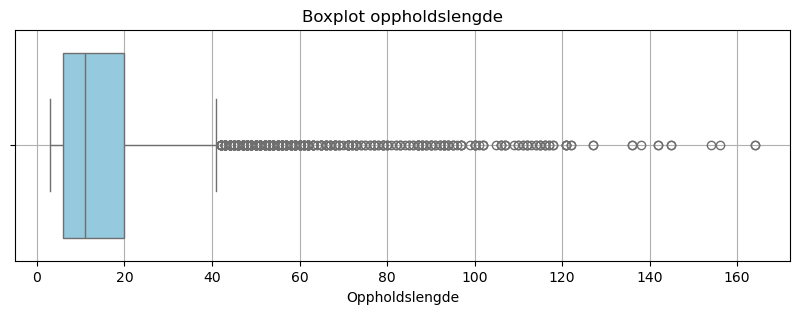

In [1554]:
plt.figure(figsize=(10, 3))
sns.boxplot(x=y_train, color='skyblue')

plt.title('Boxplot oppholdslengde', fontsize=12) 
plt.xlabel('Oppholdslengde', fontsize=10) 

plt.grid(True)
plt.show()

Visualiserer deretter målvariabelen oppholdslengde med historgram for å se fordelingen

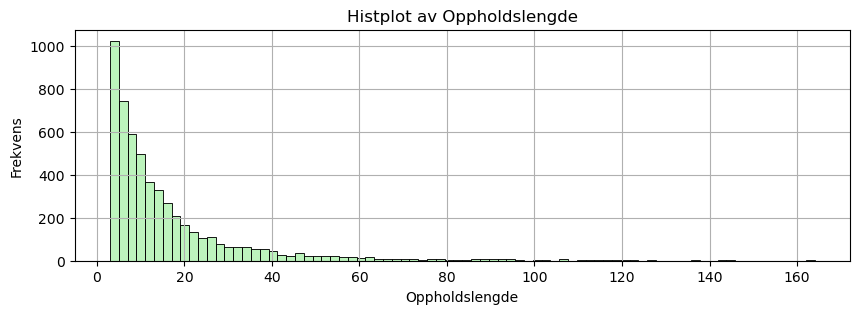

In [1555]:
plt.figure(figsize=(10, 3))
sns.histplot(x=y_train, bins=80, color='lightgreen', stat='count', alpha=0.6)

plt.title('Histplot av Oppholdslengde', fontsize=12) 
plt.xlabel('Oppholdslengde', fontsize=10) 
plt.ylabel('Frekvens', fontsize=10) 

plt.grid(True)
plt.show()

Looper nå gjennom resten av variablene som befinner seg i X_train og lager et boxplot av hver ikke-binære kolonne. Dette gir god innsikt i eventuell spredning for de ulike variablene.

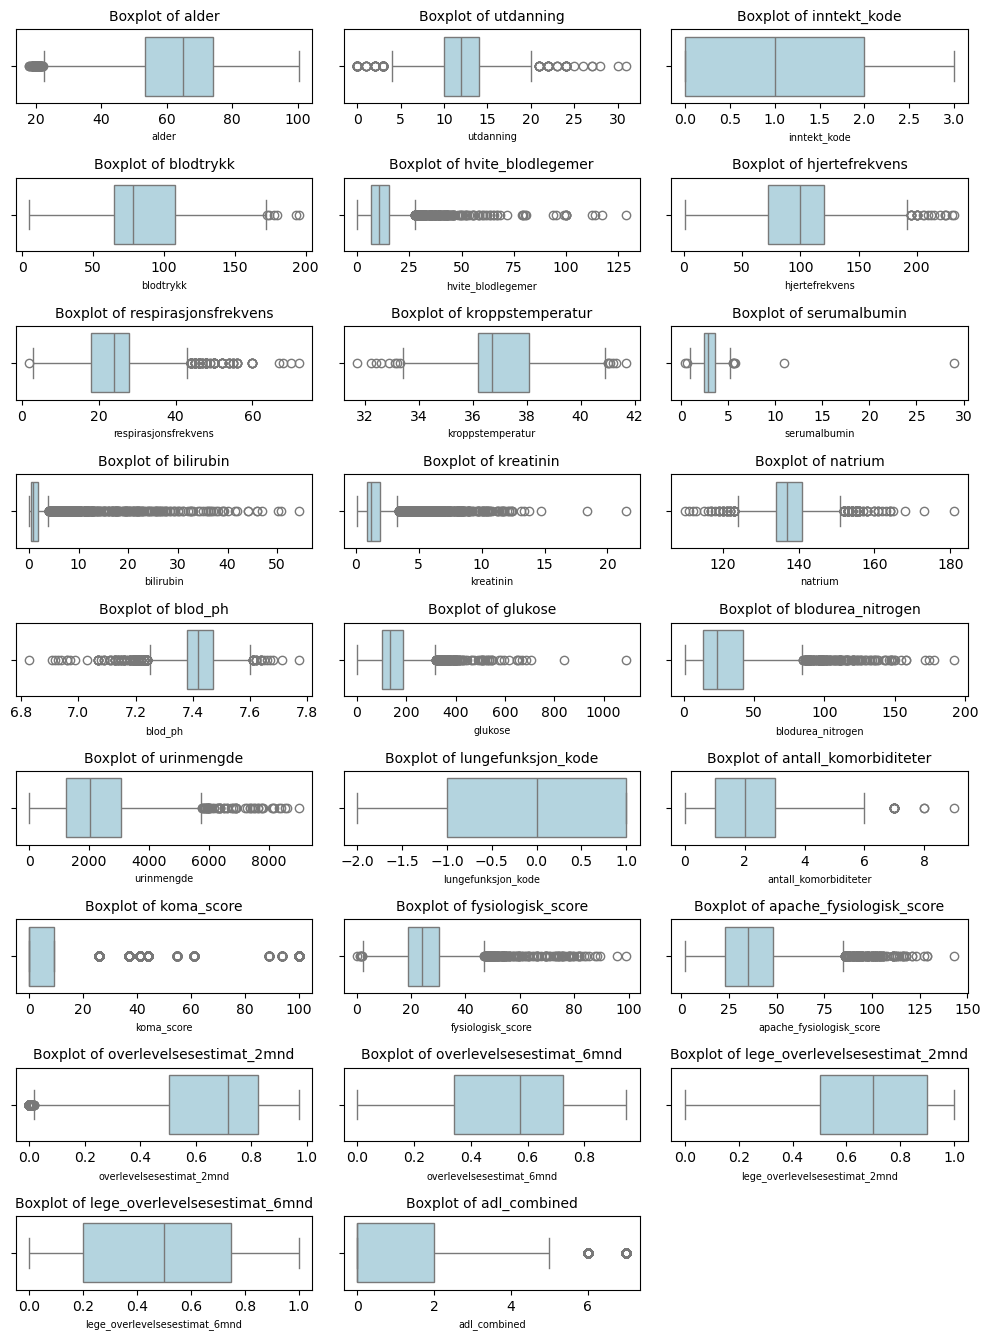

In [1556]:
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
filtered_cols = [col for col in numeric_cols if X_train[col].nunique() > 2]

num_rows = (len(filtered_cols) + 2) // 3 

fig, axs = plt.subplots(num_rows, 3, figsize=(10, 1.5 * num_rows))

for i, col in enumerate(filtered_cols):
    plt.subplot(num_rows, 3, i + 1)  
    sns.boxplot(x=X_train[col], color='lightblue') 
    plt.title('Boxplot of ' + col, fontsize=10)  
    plt.xlabel(col, fontsize=7) 

for j in range(i + 1, num_rows * 3):
    fig.delaxes(axs.flatten()[j]) 

plt.tight_layout()
plt.show()

Bruker histogram for å få et innblikk i fordelingen av de ulike variablene

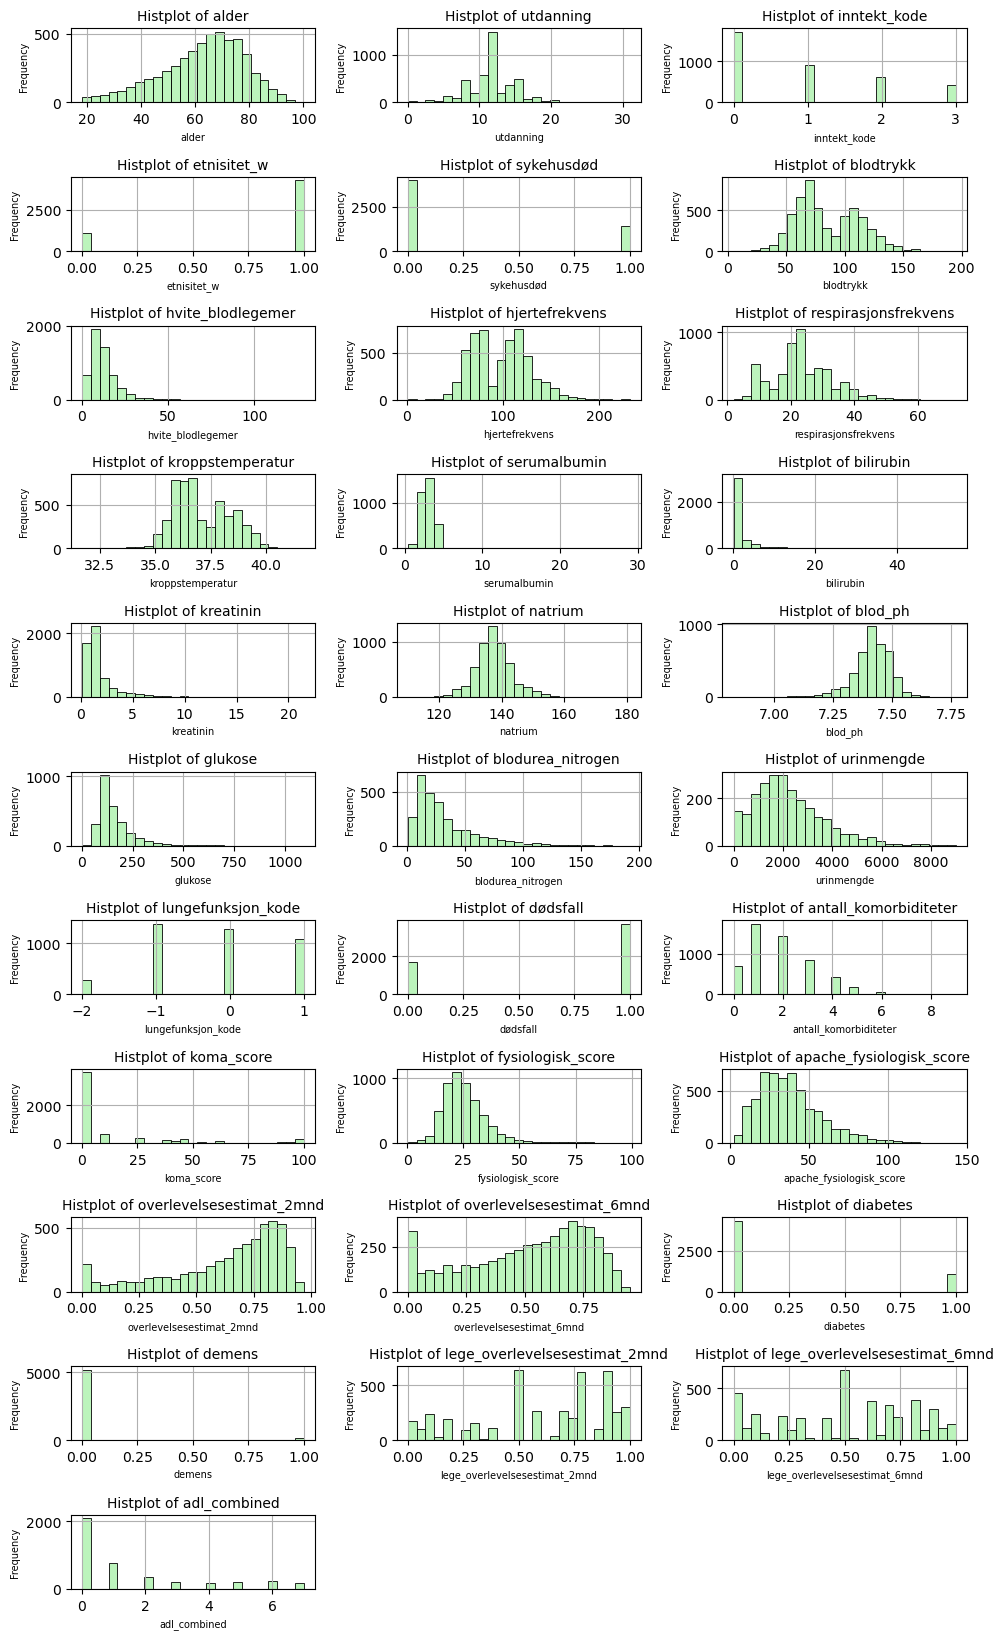

In [1557]:
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
num_rows = (len(numeric_cols) + 2) // 3

fig, axs = plt.subplots(num_rows, 3, figsize=(10, 1.5 * num_rows))

for i, col in enumerate(numeric_cols):
    plt.subplot(num_rows, 3, i + 1)
    sns.histplot(X_train[col], bins=25, color='lightgreen', alpha=0.6, stat='count')
    
    plt.title('Histplot of ' + col, fontsize=10) 
    plt.xlabel(col, fontsize=7)  
    plt.ylabel('Frequency', fontsize=7) 
    plt.grid(True)

for j in range(i + 1, num_rows * 3):
    fig.delaxes(axs.flatten()[j])

plt.tight_layout()
plt.show()



En korrelasjonsmatrise opprettes nå for å identifisere hvilke parametere som er mest relevante for sykehusopphold. Først visualiseres korrelasjonen ved hjelp av et søylediagram, med fokus på sammenhengen med vår målvariabel, "oppholdslengde". Det er viktig å merke seg at korrelasjonsmatrisen kun avdekker lineære sammenhenger, mens dataene kan inneholde også ikke-lineære relasjoner. Derfor bør konklusjoner trekkes med forsiktighet, men analysen kan likevel gi verdifulle indikasjoner på relevante faktorer.

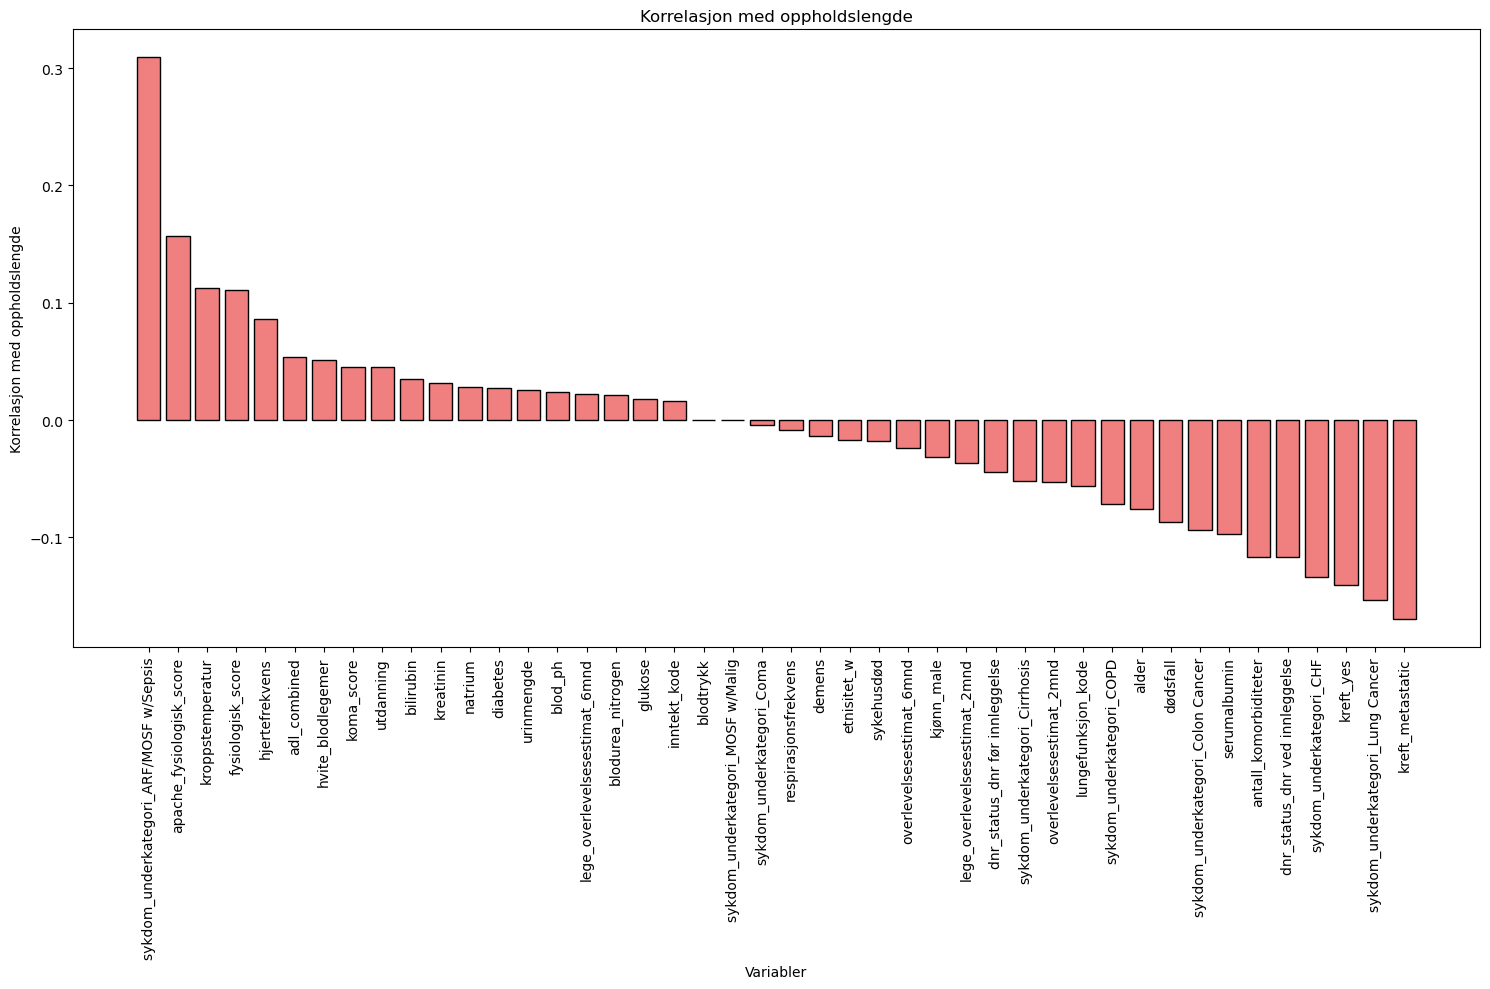

In [1558]:
# Lager en DataFrame for målvariabelen
oppholdslengde_df = pd.DataFrame(y_train, columns=["oppholdslengde"])

# Lager en kopi av X_training_data og legger til målvariabelen
combined_df = X_train.copy()
combined_df["oppholdslengde"] = oppholdslengde_df["oppholdslengde"]
correlation_matrix = combined_df.corr()

# Korrelasjon med målvariabelen sortert
correlation_with_target = correlation_matrix["oppholdslengde"].drop("oppholdslengde").sort_values(ascending=False)

plt.figure(figsize=(15, 10))
plt.bar(correlation_with_target.index, correlation_with_target.values, 
        color='lightcoral', edgecolor='black')

plt.xlabel('Variabler')
plt.ylabel('Korrelasjon med oppholdslengde')
plt.title('Korrelasjon med oppholdslengde')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

Variablene har nå blitt evaluert for korrelasjon med målvariabelen, men det er også nødvendig å undersøke korrelasjonene mellom variablene seg imellom. Neste steg er å visualisere den komplette korrelasjonsmatrisen:

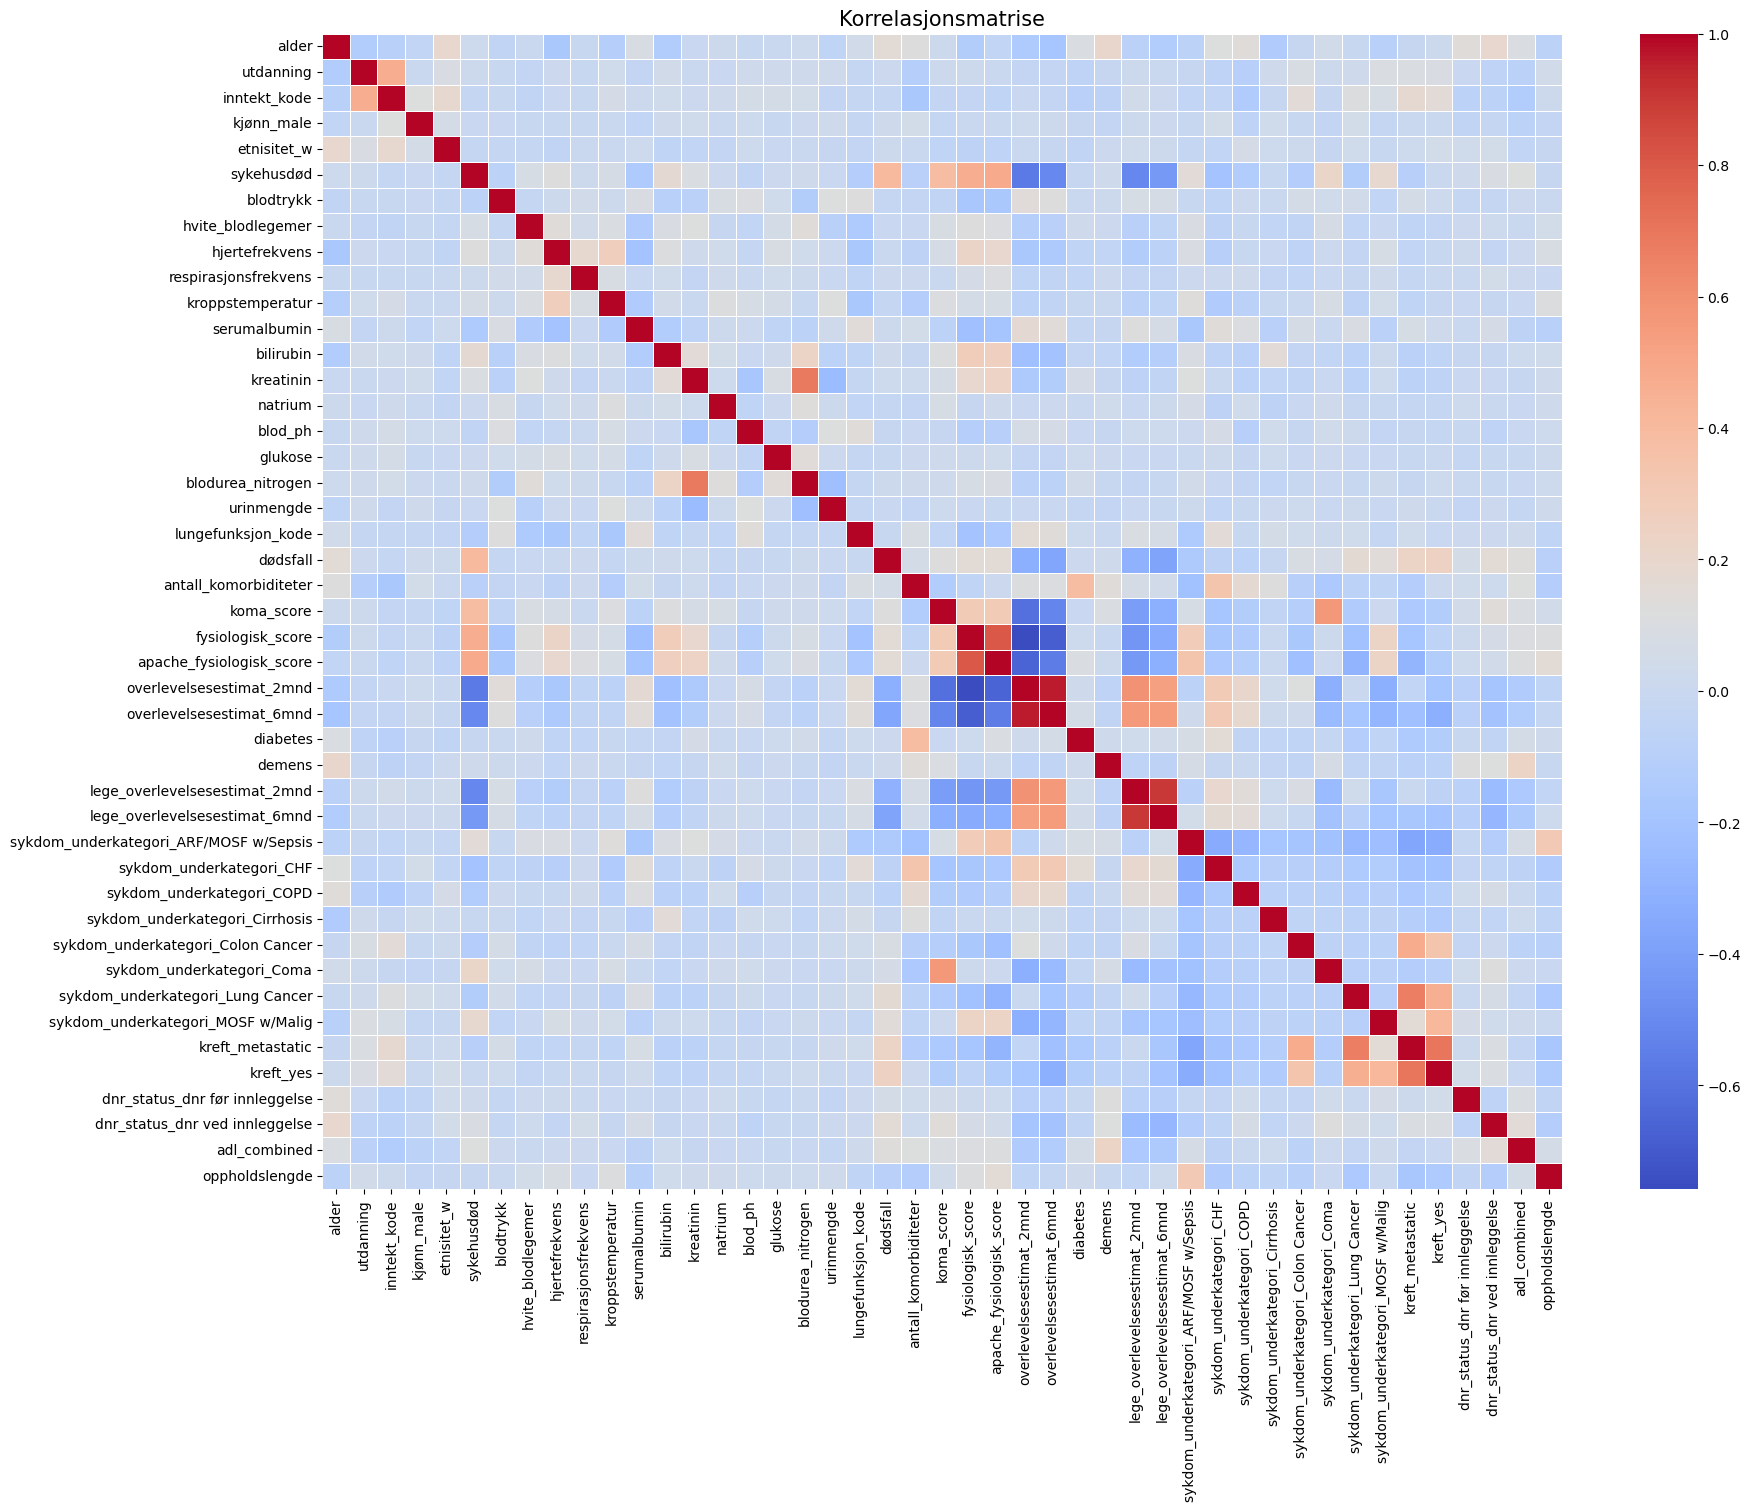

In [1559]:
plt.figure(figsize=(20, 15))
sns.heatmap(correlation_matrix, cmap='coolwarm', linewidths=0.5)
plt.title('Korrelasjonsmatrise', fontsize=15)
plt.show()

Laster opp dataen som csv filer:

In [1560]:
# Spesifiser mappenavn
folder = PROCESSED_DATA_DIR
folder.mkdir(parents=True, exist_ok=True)

# Lagrer treningsdata i den spesifiserte mappen
X_train.to_csv(f'{folder}/X_train.csv', index=False)
y_train.to_csv(f'{folder}/y_train.csv', index=False)

# Lagrer valideringsdata i den spesifiserte mappen
X_val.to_csv(f'{folder}/X_val.csv', index=False)
y_val.to_csv(f'{folder}/y_val.csv', index=False)

# Lagrer testdata i den spesifiserte mappen
X_test.to_csv(f'{folder}/X_test.csv', index=False)
y_test.to_csv(f'{folder}/y_test.csv', index=False)

#Lagrer også den kombinerte df for sample data som egen csv
final_raw_df.to_csv(folder / 'raw_df.csv')
final_sample_df.to_csv(folder / 'sample_df.csv', index=False)